In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# Get NIST data

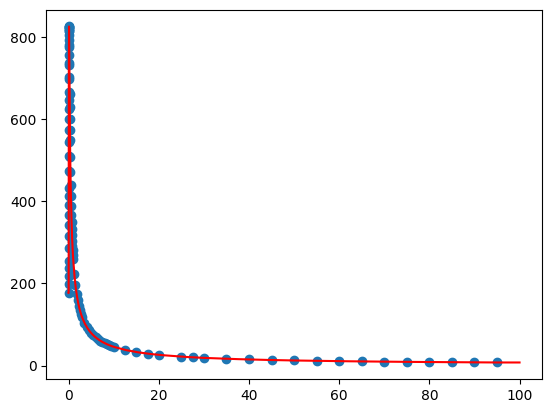

In [2]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

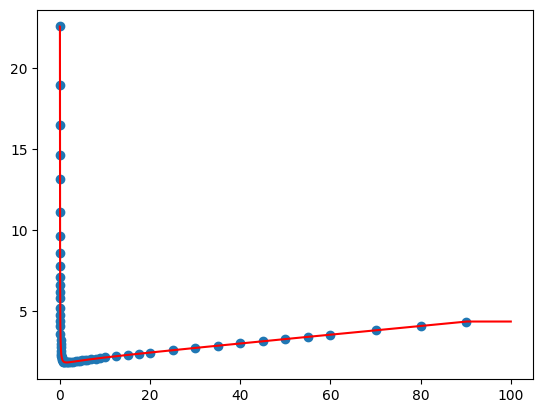

In [3]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# LET and dose statistics

In [4]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        particle_data['Dose_weights'] = particle_data['Weight']*particle_data['LET']
        particle_data['Dose_weights'] = particle_data['Dose_weights']/particle_data['Dose_weights'].sum()
        particle_data['LET_d'] = particle_data['Dose_weights']*particle_data['LET']

        LET = round(particle_data['LET_d'].sum(),2)
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        LET = 0

    #print(phsp_path + ' finished')

    return LET

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_5532\3984868068.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [5]:
print('---low LET---')

let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_LET.csv", skiprows=4)
let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_Dose.csv", skiprows=4)
print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

print('---mid LET---')

let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_LET.csv", skiprows=4)
let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_Dose.csv", skiprows=4)
print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

print('---high LET---')

let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_LET.csv", skiprows=4)
let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_Dose.csv", skiprows=4)
print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

---low LET---
LET (scorer): 0.23 keV/um
LET (phsp): 1.26 keV/um
Dose: 9.799808076138561e-09 Gy
---mid LET---
LET (scorer): 1.16 keV/um
LET (phsp): 10.98 keV/um
Dose: 2.308504143400114e-08 Gy
---high LET---
LET (scorer): 2.08 keV/um
LET (phsp): 16.28 keV/um
Dose: 1.3058160774903632e-08 Gy


## Read in MONAS data

In [6]:
data = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_LOW\MKModel_SMKM.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SMKM_low = pd.concat([new, data])

data = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_MID\MKModel_SMKM.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SMKM_mid = pd.concat([new, data])

data = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_HIGH\MKModel_SMKM.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SMKM_high = pd.concat([new, data])

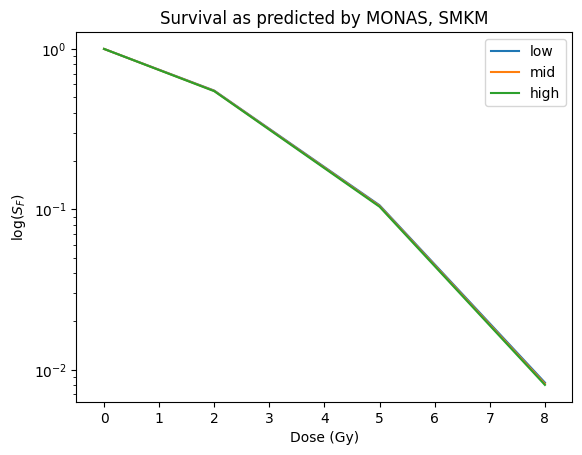

In [7]:
plt.title('Survival as predicted by MONAS, SMKM')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.plot(SMKM_low['# Dose[Gy]'], SMKM_low[' Survival'], label = 'low')
plt.plot(SMKM_mid['# Dose[Gy]'], SMKM_mid[' Survival'], label = 'mid')
plt.plot(SMKM_high['# Dose[Gy]'], SMKM_high[' Survival'], label = 'high')
plt.yscale('log')
plt.xlim([-0.5, 8.5])
# plt.ylim([0.00001, 3])
plt.legend()

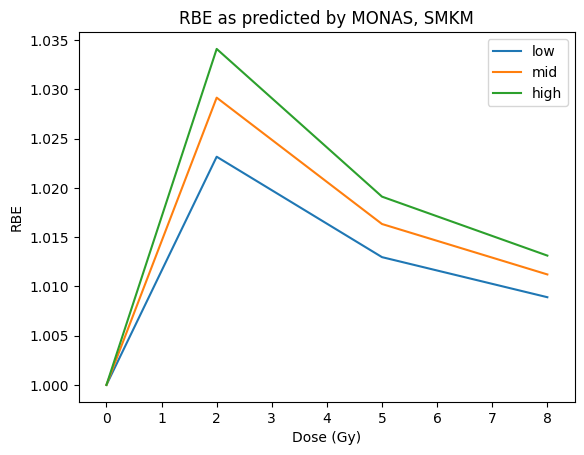

In [8]:
plt.title('RBE as predicted by MONAS, SMKM')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.plot(SMKM_low['# Dose[Gy]'], SMKM_low[' RBE'], label = 'low')
plt.plot(SMKM_mid['# Dose[Gy]'], SMKM_mid[' RBE'], label = 'mid')
plt.plot(SMKM_high['# Dose[Gy]'], SMKM_high[' RBE'], label = 'high')
plt.xlim([-0.5, 8.5])
# plt.ylim([0.00001, 3])
plt.legend()

In [9]:
data = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_LOW\MKModel_StaurationCorrected.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SatCorr_low = pd.concat([new, data])

data = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_MID\MKModel_StaurationCorrected.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SatCorr_mid = pd.concat([new, data])

data = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_HIGH\MKModel_StaurationCorrected.csv", skiprows=8)
new = pd.DataFrame([{'# Dose[Gy]': 0, ' Survival': 1, ' SurvivalStd': 0, ' RBE': 1, ' RBEStd': 0}])
SatCorr_high = pd.concat([new, data])


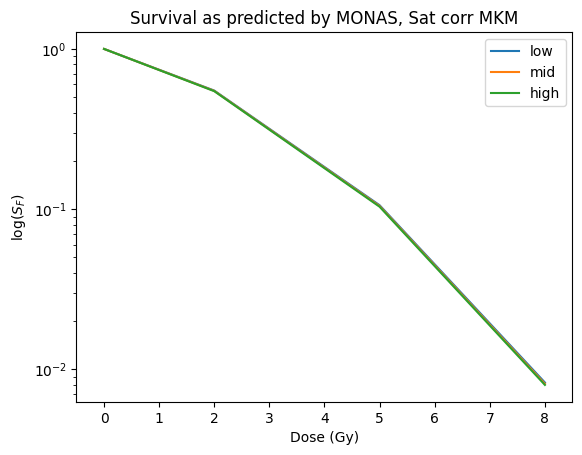

In [10]:
plt.title('Survival as predicted by MONAS, Sat corr MKM')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.plot(SatCorr_low['# Dose[Gy]'], SatCorr_low[' Survival'], label = 'low')
plt.plot(SatCorr_mid['# Dose[Gy]'], SatCorr_mid[' Survival'], label = 'mid')
plt.plot(SatCorr_high['# Dose[Gy]'], SatCorr_high[' Survival'], label = 'high')
plt.yscale('log')
plt.xlim([-0.5, 8.5])
plt.legend()

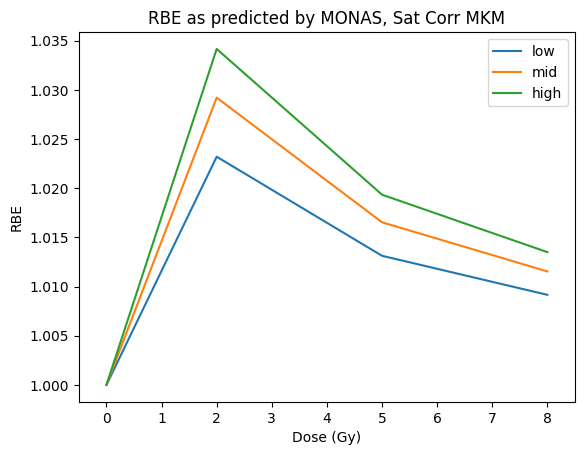

In [11]:
plt.title('RBE as predicted by MONAS, Sat Corr MKM')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.plot(SatCorr_low['# Dose[Gy]'], SatCorr_low[' RBE'], label = 'low')
plt.plot(SatCorr_mid['# Dose[Gy]'], SatCorr_mid[' RBE'], label = 'mid')
plt.plot(SatCorr_high['# Dose[Gy]'], SatCorr_high[' RBE'], label = 'high')
plt.xlim([-0.5, 8.5])
# plt.ylim([0.00001, 3])
plt.legend()

# Analysis of lineal energy spectra

In [ ]:
ydata_low = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_LOW\ySpecfile.txt", skiprows=1, header=None, sep='\s+')
ydata_mid = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_MID\ySpecfile.txt", skiprows=1, header=None, sep='\s+')
ydata_high = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_HIGH\ySpecfile.txt", skiprows=1, header=None, sep='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_5532\1786496539.py:1: SyntaxWarning: invalid escape sequence '\s'
  ydata_low = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_LOW\ySpecfile.txt", skiprows=1, header=None, sep='\s+')
C:\Users\linux\AppData\Local\Temp\ipykernel_5532\1786496539.py:2: SyntaxWarning: invalid escape sequence '\s'
  ydata_mid = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_MID\ySpecfile.txt", skiprows=1, header=None, sep='\s+')
C:\Users\linux\AppData\Local\Temp\ipykernel_5532\1786496539.py:3: SyntaxWarning: invalid escape sequence '\s'
  ydata_high = pd.read_csv(r"../TOPAS_data\OUTPUTS_MONAS_HIGH\ySpecfile.txt", skiprows=1, header=None, sep='\s+')


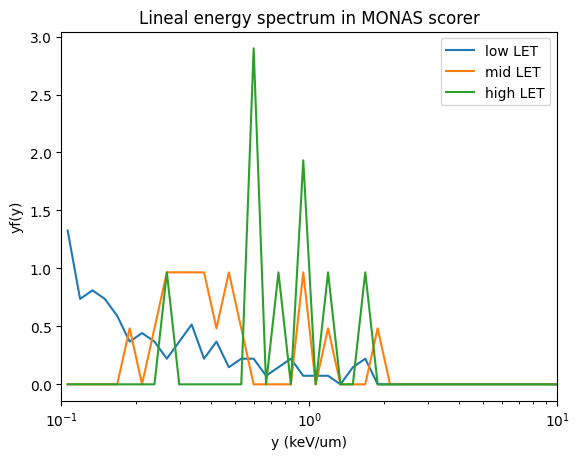

In [ ]:
plt.plot(ydata_low.iloc[:,0], ydata_low.iloc[:,3], label='low LET A')
plt.plot(ydata_mid.iloc[:,0], ydata_mid.iloc[:,3], label='mid LET')
plt.plot(ydata_high.iloc[:,0], ydata_high.iloc[:,3], label='high LET')
plt.xscale('log')
plt.xlim([0.1,10])
plt.xlabel('y (keV/um)')
plt.ylabel('yf(y)')
plt.title('Lineal energy spectrum in MONAS scorer')
plt.legend()